In [33]:
import json
import scipy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from functools import cmp_to_key
import copy
import PIL

sns.set_theme(font='Fira Code', font_scale=0.8, style='whitegrid')
sns.set_style({'grid.linestyle': ':'})

import warnings
warnings.filterwarnings('ignore')

In [2]:
def get_filename(crawl, climb, size, mass, count):
    return f'../data/crawl_{crawl}_climb_{climb}_size_{size}_mass_{mass}_cnt_{count}.json';

In [5]:
def auto_scale(a, n = 10):
    new_a = copy.deepcopy(a)
    
    min_x = min([p['x'] for p in a])
    min_y = min([p['y'] for p in a])

    for p in new_a:
        p['x'] -= min_x
        p['y'] -= min_y

    scale = max([p['x'] for p in new_a])

    for p in new_a:
        p['x'] /= scale
        p['y'] /= scale

    return new_a

In [6]:
def get_boundary(a, n = 10):
    max_x = 0

    for p in a:
        max_x = max(max_x, p['x'])
        
    chunk =  max_x / n;
    best = [0 for i in range(n)]

    # filler = [{'x': 0, 'y': 0}]
    
    for p in a:
        h = min(n-1, math.floor(p['x'] / chunk))
        best[h] = max(best[h], p['y'])

    def non_zero(p):
        return p['y'] != 0
        
    ans = [{ 'x': float(chunk*i) + chunk / 2, 'y': best[i] } for i in range(n)]

    fx = -chunk / 2
    lx = 1 + chunk / 2

    return [{'x': fx, 'y': 0}] + ans + [{'x': lx, 'y': 0}]

In [7]:
def build(a, n = 10):
    return get_boundary(auto_scale(a), n)

In [9]:
crawl, climb, size, mass, count = '0.4', '0.4', '0', '0', 100
filename = get_filename(crawl, climb, size, mass, count)
with open(filename, 'r') as file:
    data = json.load(file)
build(data['points'])

[{'x': -0.05, 'y': 0},
 {'x': 0.05, 'y': 0.11075417331396023},
 {'x': 0.15000000000000002, 'y': 0.14875294303472406},
 {'x': 0.25, 'y': 0.17505903689051922},
 {'x': 0.35000000000000003, 'y': 0.19545076267354872},
 {'x': 0.45, 'y': 0.24987606286972402},
 {'x': 0.55, 'y': 0.25643943891985055},
 {'x': 0.6500000000000001, 'y': 0.23651873473955884},
 {'x': 0.7500000000000001, 'y': 0.16878010540119326},
 {'x': 0.8500000000000001, 'y': 0.13637824987373146},
 {'x': 0.9500000000000001, 'y': 0.10535459002566998},
 {'x': 1.05, 'y': 0}]

In [10]:
count, size, mass = '300', '0', '0'
crawls = ['0', '0.2', '0.4', '0.6', '0.8', '1']
climbs = ['0', '0.2', '0.4', '0.6', '0.8', '1']

In [77]:
def get_loss(actual_points, simulated_points):
    a = np.array([p['y'] for p in build(actual_points)])
    s = np.array([p['y'] for p in build(simulated_points)])
    return np.mean((a - s)**2)

In [80]:
raw = np.array(PIL.Image.open('../data/ss_4950.png').convert('RGB'))
n, m = len(raw), len(raw[0])
points = []
for i in range(n):
    for j in range(22, m):
        if raw[i][j][0] >= 67:
            points.append({'x': j, 'y': i})
points_4950 = points
climb_4950, crawl_4950, min_loss = '', '', 1e9
for i, climb in enumerate(climbs):
    for j, crawl in enumerate(crawls):
        ax = axes[i, j]
        filename = get_filename(crawl, climb, size, mass, count)
        with open(filename, 'r') as file:
            data = json.load(file)
        loss = get_loss(data['points'], points)
        if loss < min_loss:
            min_loss = loss
            climb_4950 = climb
            crawl_4950 = crawl
print(climb_4950, crawl_4950, min_loss)

0.4 1 0.0006102770778731432


In [81]:
raw = np.array(PIL.Image.open('../data/ss_5783.png').convert('RGB'))
n, m = len(raw), len(raw[0])
points = []
for i in range(n):
    for j in range(22, m):
        if raw[i][j][0] >= 67:
            points.append({'x': j, 'y': i})
points_5783 = points
climb_5783, crawl_5783, min_loss = '', '', 1e9
for i, climb in enumerate(climbs):
    for j, crawl in enumerate(crawls):
        ax = axes[i, j]
        filename = get_filename(crawl, climb, size, mass, count)
        with open(filename, 'r') as file:
            data = json.load(file)
        loss = get_loss(data['points'], points)
        if loss < min_loss:
            min_loss = loss
            climb_5783 = climb
            crawl_5783 = crawl
print(climb_5783, crawl_5783, min_loss)

0.4 1 0.00048813490330468044


In [82]:
raw = np.array(PIL.Image.open('../data/ss_9700.png').convert('RGB'))
n, m = len(raw), len(raw[0])
points = []
for i in range(n):
    for j in range(22, m):
        if raw[i][j][0] >= 67:
            points.append({'x': j, 'y': i})
points_9700 = points
climb_9700, crawl_9700, min_loss = '', '', 1e9
for i, climb in enumerate(climbs):
    for j, crawl in enumerate(crawls):
        ax = axes[i, j]
        filename = get_filename(crawl, climb, size, mass, count)
        with open(filename, 'r') as file:
            data = json.load(file)
        loss = get_loss(data['points'], points)
        if loss < min_loss:
            min_loss = loss
            climb_9700 = climb
            crawl_9700 = crawl
print(climb_9700, crawl_9700, min_loss)

0.6 1 0.0014281518695293024


In [87]:
def display(points, ax, main_color = '#222222', fill_color = '#cfcfcf', fade = False, n = 10):
    boundary = build(points)
        
    rows = []
    
    for i in range(len(boundary)):
        rows.append([boundary[i]['x'], -boundary[i]['y']])
        
    df = pd.DataFrame(rows, columns=['x', 'y'])

    ax.plot(
        df['x'],
        df['y'],
        color=main_color,
        linewidth=1,
        zorder=1,
        alpha=0.2 if fade else 1.0,
    )
    ax.scatter(
        df['x'],
        df['y'],
        c=fill_color,
        s=10,
        zorder=2,
        linewidth=1,
        edgecolor=main_color,
        alpha=0.1 if fade else 1.0,
    )
    
    ax.set_xlim([-0.1, 1.1])
    ax.set_ylim([-0.8, 0.1])

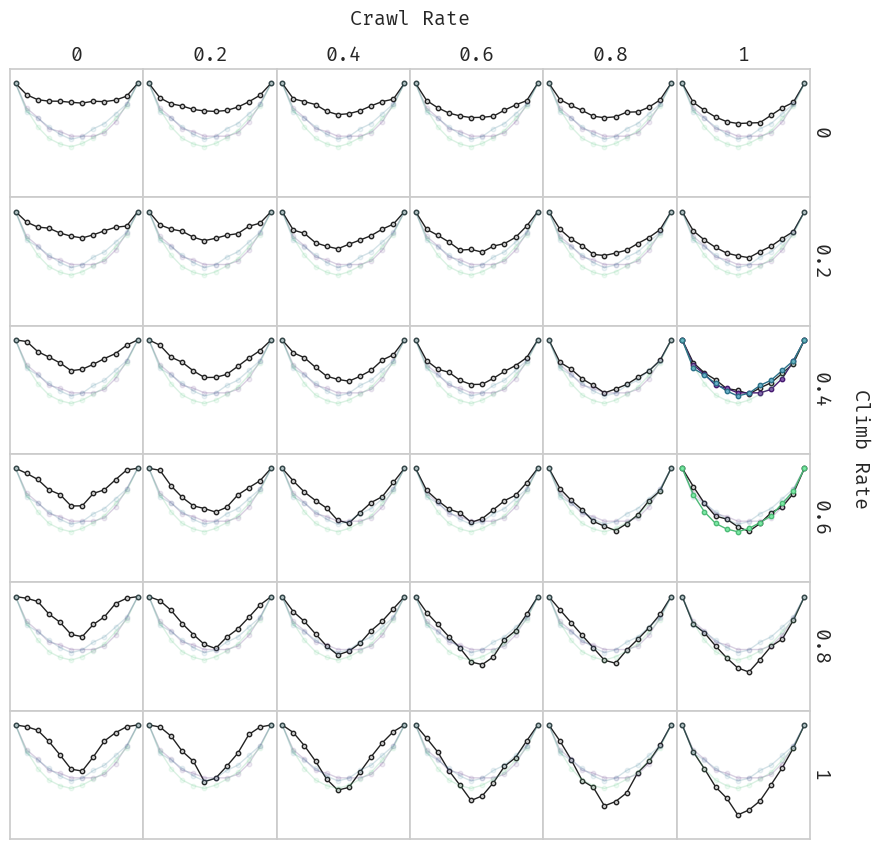

In [88]:
fig, axes = plt.subplots(
    len(climbs),
    len(crawls),
    figsize=(10, 10),
    sharex=True,
    sharey=True,
)

for i, climb in enumerate(climbs):
    for j, crawl in enumerate(crawls):
        ax = axes[i, j]
        filename = get_filename(crawl, climb, size, mass, count)
        with open(filename, 'r') as file:
            data = json.load(file)
        display(data['points'], ax)

        display(points_4950, ax, '#451A6F', '#855AaF', climb != climb_4950 or crawl != crawl_4950)
        display(points_5783, ax, '#2B7189', '#6Bb1c9', climb != climb_5783 or crawl != crawl_5783)
        display(points_9700, ax, '#4DBA76', '#7DEAa6', climb != climb_9700 or crawl != crawl_9700)

        if i == 0:
            ax.set_title(f'{crawl}', size=14)
        
        ax.tick_params(left=False, right=False, top=False, bottom=False)

        if j == len(crawls) - 1:
            ax.yaxis.set_label_position('right')
            ax.set_ylabel(f'{climb}', rotation=270, labelpad=14, size=14)
        else:
            ax.set_ylabel(None)
        
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(None)
        
# fig.supylabel('y', fontsize=14, x=0.04)
fig.supxlabel('Crawl Rate', fontsize=14, y=0.92)
fig.text(
    x=0.95,
    y=0.5,
    s='Climb Rate',
    fontsize=14,
    rotation=270,
    verticalalignment='center',
    horizontalalignment='center'
)

fig.subplots_adjust(wspace=0, hspace=0, left=0.1, right=0.9)